# P6h Training Drawdown Constraint Evaluation

## tl;dr

The executed result below determines whether a `-20%` training maximum-drawdown hard constraint is feasible with the preregistered four-candidate parameter grid. The conclusion is generated from the same candidate table used by the checks and chart.

In [1]:
from pathlib import Path
from dataclasses import asdict
import base64
from io import BytesIO
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest_wfa import (
    DEFAULT_PARAM_GRID,
    ExecutionConfig,
    PortfolioSimulator,
    _optimization_score,
    build_walk_forward_folds,
    combine_oos_equity,
    load_price_history,
    prepare_price_history,
    summarize_portfolio,
)

START_DATE = "2024-01-01"
END_DATE = "2026-09-02"
N_SPLITS = 3
TRAIN_DD_FLOOR = -0.20
P6G_REFERENCE = {
    "final_equity_rounded": 3_731_924,
    "cagr_percent_rounded": 11.46,
    "max_drawdown_percent_rounded": -18.02,
}
EXECUTION = ExecutionConfig(
    initial_capital=3_000_000,
    max_positions=20,
    lot_size=100,
    commission_bps=10,
    slippage_bps=5,
    allocation_policy="remaining-slots-capped",
    max_entry_weight=0.10,
)

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.edgecolor": "#30343b",
    "axes.grid": True,
    "grid.color": "#dfe3e8",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})

## Context & Methods

This is a preregistered risk-constraint experiment. Candidate selection uses only each expanding training window; the next disjoint block remains out of sample.

### Key Assumptions

- The controlling specification is `docs/P6H_PREREGISTRATION.md`.
- `stock_data.db` is opened read-only by `load_price_history`.
- The parameter grid, score, 100-share lot, costs, and `remaining-slots-capped` allocation are unchanged from P6g.
- A candidate is feasible only when its training maximum drawdown is finite and at least `-20%`.
- A fold with zero feasible candidates fails; there is no fallback to unconstrained selection.
- Current `fundamentals.scalecat` is used historically because point-in-time membership is unavailable.

## Data

### 1. Load and validate the read-only price history

In [2]:
database_path = PROJECT_ROOT / "stock_data.db"
raw_prices = load_price_history(database_path, start_date=START_DATE, end_date=END_DATE)
prepared_prices, data_quality = prepare_price_history(raw_prices)

quality_table = pd.DataFrame(
    [{"Measure": key.replace("_", " ").title(), "Value": value} for key, value in data_quality.items()]
)
display(quality_table)

assert not prepared_prices.empty
assert prepared_prices["date"].min() <= pd.Timestamp(START_DATE)
assert prepared_prices["date"].max() >= pd.Timestamp(END_DATE)

,Measure,Value
0,Input Rows,1416163
1,Input Codes,1571
2,Eligible Rows,1320842
3,Eligible Codes,1463
4,Unverified Codes,102
5,Invalid Ohlc Codes,12
6,Excluded Codes,108
7,Explicit Adjustment Events,295


## Results

### 2. Evaluate every parameter candidate on every training window

The table is the complete preregistered grid: four candidates in each of three folds. `Eligible` is determined before any test-period simulation.

In [3]:
simulator = PortfolioSimulator(prepared_prices, EXECUTION)
evaluation_dates = [
    date for date in simulator.trading_dates
    if pd.Timestamp(START_DATE) <= date <= pd.Timestamp(END_DATE)
]
folds = build_walk_forward_folds(evaluation_dates, N_SPLITS)

candidate_rows = []
for fold_number, (train_dates, test_dates) in enumerate(folds, start=1):
    for candidate_index, params in enumerate(DEFAULT_PARAM_GRID, start=1):
        train_equity, train_trades = simulator.run(
            params,
            start_date=train_dates[0],
            end_date=train_dates[-1],
        )
        train_summary = summarize_portfolio(
            train_equity,
            train_trades,
            initial_capital=EXECUTION.initial_capital,
        )
        candidate_rows.append({
            "fold": fold_number,
            "candidate": candidate_index,
            **asdict(params),
            "train_start": train_dates[0],
            "train_end": train_dates[-1],
            "test_start": test_dates[0],
            "test_end": test_dates[-1],
            "optimization_score": _optimization_score(train_summary, 5),
            "train_trades": train_summary["trades"],
            "train_cagr": train_summary["cagr"],
            "train_max_drawdown": train_summary["max_drawdown"],
        })

candidates = pd.DataFrame(candidate_rows)
candidates["eligible"] = (
    np.isfinite(candidates["train_max_drawdown"])
    & (candidates["train_max_drawdown"] >= TRAIN_DD_FLOOR)
)

candidate_view = candidates[
    [
        "fold", "candidate", "dip_threshold", "stop_loss", "trailing_stop",
        "market_threshold", "train_trades", "train_cagr",
        "train_max_drawdown", "optimization_score", "eligible",
    ]
].copy()
candidate_view["train_cagr"] = candidate_view["train_cagr"].map(lambda value: f"{value:.2%}")
candidate_view["train_max_drawdown"] = candidate_view["train_max_drawdown"].map(lambda value: f"{value:.2%}")
candidate_view["optimization_score"] = candidate_view["optimization_score"].map(lambda value: f"{value:.4f}")
display(candidate_view)

assert len(candidates) == N_SPLITS * len(DEFAULT_PARAM_GRID)
assert (candidates.groupby("fold").size() == len(DEFAULT_PARAM_GRID)).all()

,fold,candidate,dip_threshold,stop_loss,trailing_stop,market_threshold,train_trades,train_cagr,train_max_drawdown,optimization_score,eligible
0,1,1,0.98,0.10,0.10,0.4,135,-7.95%,-18.79%,-0.2674,True
1,1,2,0.95,0.10,0.15,0.4,98,-9.01%,-17.03%,-0.2603,True
2,1,3,1.00,0.08,0.10,0.4,144,-15.61%,-19.67%,-0.3528,True
3,1,4,0.97,0.12,0.12,0.4,95,-14.10%,-16.85%,-0.3095,True
4,2,1,0.98,0.10,0.10,0.4,258,-16.81%,-32.66%,-0.4946,False
5,2,2,0.95,0.10,0.15,0.4,165,-14.01%,-28.23%,-0.4223,False
6,2,3,1.00,0.08,0.10,0.4,270,-18.46%,-31.31%,-0.4977,False
7,2,4,0.97,0.12,0.12,0.4,187,-14.93%,-25.81%,-0.4075,False
8,3,1,0.98,0.10,0.10,0.4,327,-2.05%,-32.66%,-0.3471,False
9,3,2,0.95,0.10,0.15,0.4,207,-1.88%,-28.23%,-0.3010,False


### 3. Inspect constraint feasibility by fold

,fold,parameter_candidates,eligible_parameter_candidates,best_train_max_drawdown,worst_train_max_drawdown,constraint_passed
0,1,4,4,-0.168458,-0.196695,True
1,2,4,0,-0.258129,-0.326584,False
2,3,4,0,-0.259621,-0.326584,False



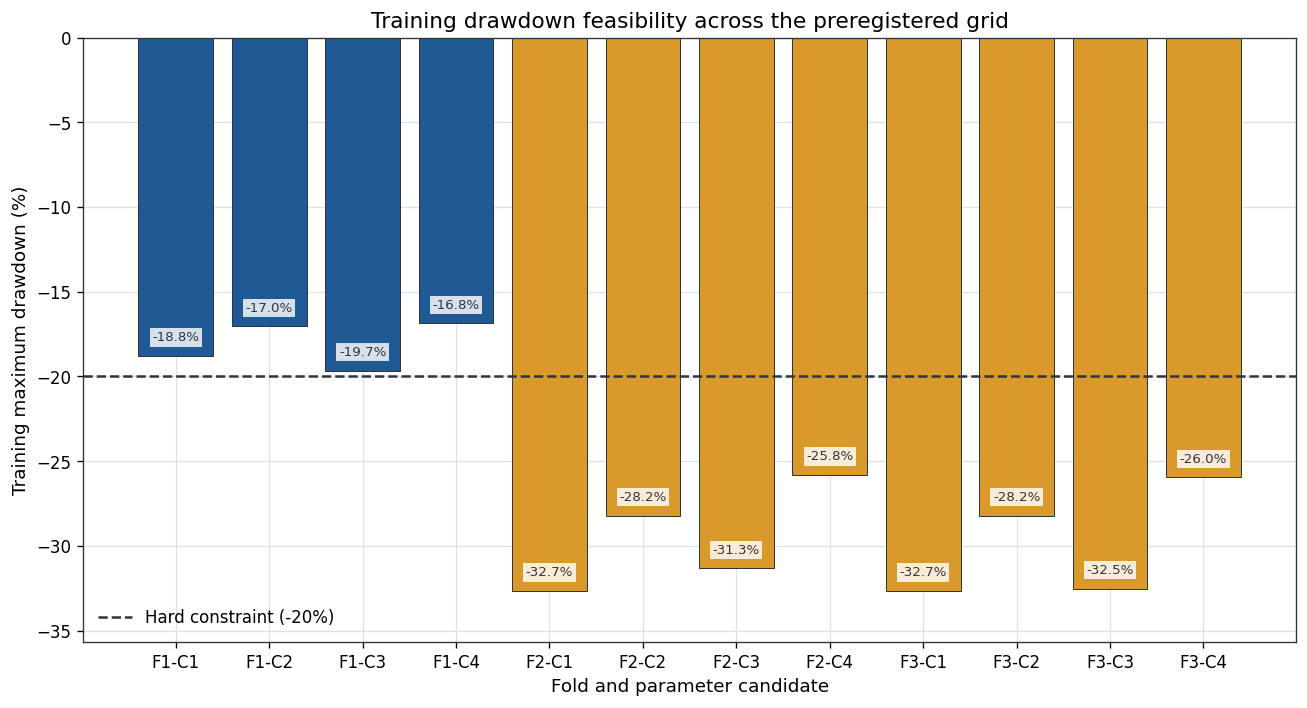

In [4]:
eligibility = (
    candidates.groupby("fold")
    .agg(
        parameter_candidates=("candidate", "size"),
        eligible_parameter_candidates=("eligible", "sum"),
        best_train_max_drawdown=("train_max_drawdown", "max"),
        worst_train_max_drawdown=("train_max_drawdown", "min"),
    )
    .reset_index()
)
eligibility["constraint_passed"] = eligibility["eligible_parameter_candidates"] > 0
display(eligibility)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#1f5a94" if eligible else "#d99a2b" for eligible in candidates["eligible"]]
x = np.arange(len(candidates))
bars = ax.bar(x, candidates["train_max_drawdown"] * 100, color=colors, edgecolor="#30343b", linewidth=0.6)
ax.axhline(TRAIN_DD_FLOOR * 100, color="#30343b", linestyle="--", linewidth=1.5, label="Hard constraint (-20%)")
ax.set_xticks(x, [f"F{fold}-C{candidate}" for fold, candidate in zip(candidates["fold"], candidates["candidate"])])
ax.set_ylabel("Training maximum drawdown (%)")
ax.set_xlabel("Fold and parameter candidate")
ax.set_title("Training drawdown feasibility across the preregistered grid")
ax.legend(frameon=False, loc="lower left")
for bar, value in zip(bars, candidates["train_max_drawdown"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.7,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#30343b",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.5},
    )
ax.set_ylim(min(-35, candidates["train_max_drawdown"].min() * 100 - 3), 0)
fig.tight_layout()
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=120, bbox_inches="tight")
image_data = base64.b64encode(image_buffer.getvalue()).decode("ascii")
display(HTML(
    '<img style="max-width:100%;height:auto" '
    'alt="Training maximum drawdown for four candidates in each of three folds; '
    'all fold 1 candidates pass the negative twenty percent floor, while all '
    'fold 2 and fold 3 candidates fail it." '
    f'src="data:image/png;base64,{image_data}">'
))
plt.close(fig)

### 4. Reproduce the unconstrained P6g baseline without using test results for selection

This local reconstruction chooses the highest training score with the original grid-order tie break, then simulates only that fold's disjoint test block.

In [5]:
baseline_selected = (
    candidates.sort_values(
        ["fold", "optimization_score", "candidate"],
        ascending=[True, False, True],
        kind="stable",
    )
    .groupby("fold", as_index=False)
    .first()
)

oos_curves = []
oos_trades = []
fold_test_rows = []
for _, selected in baseline_selected.iterrows():
    params = DEFAULT_PARAM_GRID[int(selected["candidate"]) - 1]
    test_equity, test_trades = simulator.run(
        params,
        start_date=selected["test_start"],
        end_date=selected["test_end"],
    )
    test_summary = summarize_portfolio(
        test_equity,
        test_trades,
        initial_capital=EXECUTION.initial_capital,
    )
    oos_curves.append(test_equity)
    if not test_trades.empty:
        oos_trades.append(test_trades.assign(fold=int(selected["fold"])))
    fold_test_rows.append({
        "fold": int(selected["fold"]),
        "selected_candidate": int(selected["candidate"]),
        "train_cagr": selected["train_cagr"],
        "train_max_drawdown": selected["train_max_drawdown"],
        "eligible_under_p6h": bool(selected["eligible"]),
        "test_total_return": test_summary["total_return"],
        "test_max_drawdown": test_summary["max_drawdown"],
        "test_min_cash": float(test_equity["cash"].min()),
        "test_max_positions": int(test_equity["positions"].max()),
    })

combined_equity = combine_oos_equity(oos_curves, EXECUTION.initial_capital)
combined_trades = pd.concat(oos_trades, ignore_index=True)
baseline_summary = summarize_portfolio(
    combined_equity,
    combined_trades,
    initial_capital=EXECUTION.initial_capital,
)
fold_tests = pd.DataFrame(fold_test_rows)
display(fold_tests)
display(pd.DataFrame([baseline_summary]))

assert round(baseline_summary["final_equity"]) == P6G_REFERENCE["final_equity_rounded"]
assert round(baseline_summary["cagr"] * 100, 2) == P6G_REFERENCE["cagr_percent_rounded"]
assert round(baseline_summary["max_drawdown"] * 100, 2) == P6G_REFERENCE["max_drawdown_percent_rounded"]
assert (fold_tests["test_min_cash"] >= 0).all()
assert (fold_tests["test_max_positions"] <= EXECUTION.max_positions).all()

,fold,selected_candidate,train_cagr,train_max_drawdown,eligible_under_p6h,test_total_return,test_max_drawdown,test_min_cash,test_max_positions
0,1,2,-0.090062,-0.170285,True,-0.167040,-0.180207,897.357581,20
1,2,4,-0.149332,-0.258129,False,0.201868,-0.060042,848.857362,20
2,3,4,-0.011849,-0.259621,False,0.242598,-0.127284,1396.273023,20


,start_date,end_date,initial_capital,final_equity,total_return,cagr,max_drawdown,annualized_volatility,sharpe_zero_rate,trades,win_rate,average_positions
0,2024-08-28,2026-09-02,3000000.0,3.731924e+06,0.243975,0.114591,-0.180207,0.182866,0.724062,273,0.421245,17.930962


### 5. Apply the preregistered decision rule

In [6]:
failed_folds = eligibility.loc[~eligibility["constraint_passed"], "fold"].astype(int).tolist()
implementation_valid = not failed_folds

if implementation_valid:
    decision = "The hard constraint is feasible in every fold; continue to constrained OOS evaluation."
else:
    decision = (
        "Reject P6h for the current grid: no feasible training candidate exists in "
        + ", ".join(f"fold {fold}" for fold in failed_folds)
        + ". The preregistered rule forbids unconstrained fallback."
    )

eligibility_text = ", ".join(
    f"fold {int(row.fold)} = {int(row.eligible_parameter_candidates)}/{int(row.parameter_candidates)}"
    for row in eligibility.itertuples()
)
summary_text = (
    f"**Observed decision:** {decision}\n\n"
    f"- Feasible-candidate counts by fold: {eligibility_text}\n"
    f"- P6g baseline reproduced: CAGR {baseline_summary['cagr']:.2%}, "
    f"maximum drawdown {baseline_summary['max_drawdown']:.2%}.\n"
    "- P6h constrained CAGR and OOS drawdown are not defined because the full "
    f"constrained WFA cannot select fold {failed_folds[0] if failed_folds else 'N/A'}.\n"
)
display(Markdown(summary_text))

**Observed decision:** Reject P6h for the current grid: no feasible training candidate exists in fold 2, fold 3. The preregistered rule forbids unconstrained fallback.

- Feasible-candidate counts by fold: fold 1 = 4/4, fold 2 = 0/4, fold 3 = 0/4
- P6g baseline reproduced: CAGR 11.46%, maximum drawdown -18.02%.
- P6h constrained CAGR and OOS drawdown are not defined because the full constrained WFA cannot select fold 2.


## Takeaways

The result is a feasibility failure, not evidence that a different drawdown threshold would perform better. The preregistered `-20%` threshold and four-candidate grid remain unchanged after observing the outcome. A later experiment may expand or redesign the parameter grid, but it must be separately preregistered and must not reuse these OOS folds as tuning data.

The code-level hard constraint remains useful as an explicit opt-in guard: it rejects non-finite or below-floor training drawdowns and raises when no feasible candidate exists. It is not enabled by default.